# Team505 Preprocessing Pipeline

> **Notice:** Data splits are now generated centrally by `scripts/rebuild_clean_splits.py`.
> Please run that script once before training any models.

**Generated Splits:**
- `data/splits/train.csv`
- `data/splits/val.csv`
- `data/splits/test.csv`

**Strategy:** NIH-only, 14 classes capped at 1431, patient-wise 70/15/15 split.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
DATA_SPLITS  = PROJECT_ROOT / 'data' / 'splits'
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
DATA_META    = PROJECT_ROOT / 'data' / 'metadata'

print(f'Project root : {PROJECT_ROOT}')
print(f'Splits dir   : {DATA_SPLITS}')

Project root : C:\ChestX-ray14\Team505_phase2
Splits dir   : C:\ChestX-ray14\Team505_phase2\data\splits


In [2]:
df_train = pd.read_csv(DATA_SPLITS / 'train.csv')
df_val   = pd.read_csv(DATA_SPLITS / 'val.csv')
df_test  = pd.read_csv(DATA_SPLITS / 'test.csv')

# Normalize label column
for _df in [df_train, df_val, df_test]:
    if 'label' in _df.columns and 'target_pneumonia' not in _df.columns:
        _df['target_pneumonia'] = _df['label']
    if 'patient_id' not in _df.columns and 'pid_str' in _df.columns:
        _df['patient_id'] = _df['pid_str']


## Split Summary

In [3]:
splits = [
    ('Train', df_train),
    ('Val',   df_val),
    ('Test',  df_test),
]

print(f'{"Split":<28} {"Rows":>8} {"Pos":>6} {"Neg":>8} {"Pos%":>7} {"Ratio":>8}')
print('-' * 70)
for name, df in splits:
    n     = len(df)
    pos   = int(df['target_pneumonia'].sum())
    neg   = n - pos
    rate  = pos / n * 100 if n > 0 else 0
    ratio = f'1:{neg//pos}' if pos > 0 else 'N/A'
    print(f'{name:<28} {n:>8,} {pos:>6,} {neg:>8,} {rate:>6.2f}% {ratio:>8}')


Split                            Rows    Pos      Neg    Pos%    Ratio
----------------------------------------------------------------------
Train                          11,943  1,004   10,939   8.41%     1:10
Val                             2,611    186    2,425   7.12%     1:13
Test                            2,618    241    2,377   9.21%      1:9


## Class Distribution Charts

C:\Users\s-amm\AppData\Local\Temp\ipykernel_11528\3897188687.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)


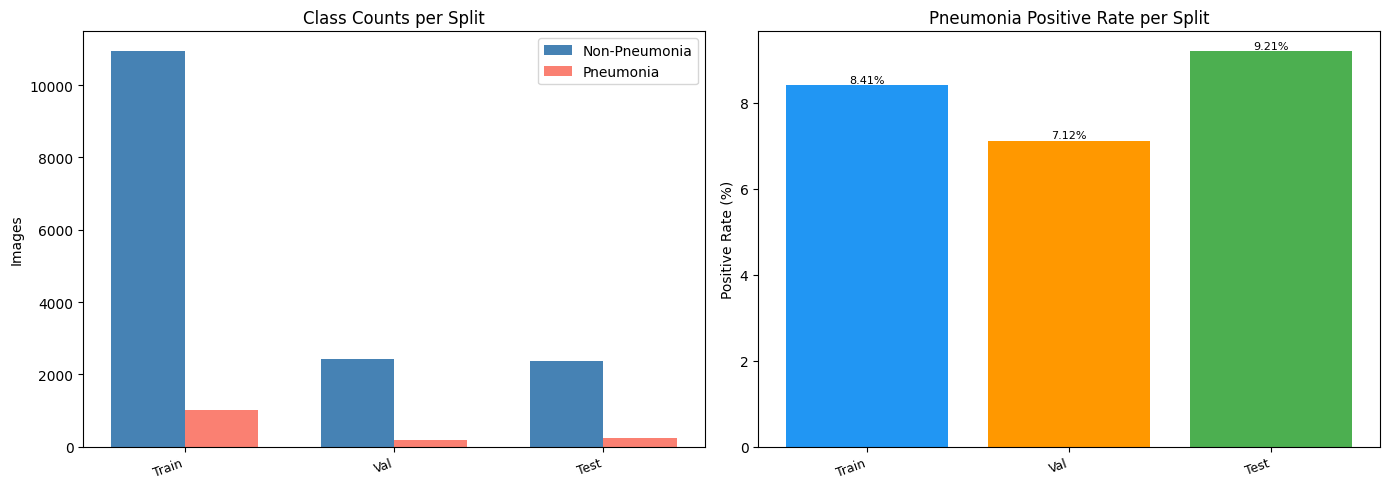

Chart saved.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Absolute counts per split
ax = axes[0]
names  = [s[0] for s in splits]
pos_c  = [int(s[1]['target_pneumonia'].sum()) for s in splits]
neg_c  = [len(s[1]) - p for s, p in zip(splits, pos_c)]
x      = np.arange(len(names))
w      = 0.35
ax.bar(x - w/2, neg_c, w, label='Non-Pneumonia', color='steelblue')
ax.bar(x + w/2, pos_c, w, label='Pneumonia',     color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
ax.set_title('Class Counts per Split')
ax.set_ylabel('Images')
ax.legend()

# Chart 2: Positive rate per split
ax = axes[1]
rates = [p / len(s[1]) * 100 for s, p in zip(splits, pos_c)]
colors = ['#2196F3','#FF9800','#4CAF50','#9C27B0','#F44336']
bars = ax.bar(names, rates, color=colors)
ax.set_title('Pneumonia Positive Rate per Split')
ax.set_ylabel('Positive Rate (%)')
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{rate:.2f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'eda' / 'split_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

## Patient Leakage Verification

In [5]:
# Identify patient ID column
def get_pid_col(df):
    for c in ['patient_id', 'Patient ID', 'pid']:
        if c in df.columns:
            return c
    return None

train_pids = set(df_train[get_pid_col(df_train)].astype(str).unique())
val_pids   = set(df_val[get_pid_col(df_val)].astype(str).unique())
test_pids  = set(df_test[get_pid_col(df_test)].astype(str).unique())

tv = train_pids & val_pids
tt = train_pids & test_pids
vt = val_pids   & test_pids

print('Patient leakage check:')
print(f'  Train ∩ Val  : {len(tv)} overlap (must be 0)')
print(f'  Train ∩ Test : {len(tt)} overlap (must be 0)')
print(f'  Val   ∩ Test : {len(vt)} overlap (must be 0)')

assert len(tv) == 0, 'LEAKAGE: Train/Val overlap'
assert len(tt) == 0, 'LEAKAGE: Train/Test overlap'
assert len(vt) == 0, 'LEAKAGE: Val/Test overlap'
print('\n✅ Zero patient leakage confirmed across all splits.')

Patient leakage check:
  Train ∩ Val  : 0 overlap (must be 0)
  Train ∩ Test : 0 overlap (must be 0)
  Val   ∩ Test : 0 overlap (must be 0)

✅ Zero patient leakage confirmed across all splits.


## Source Weight Distribution (Training Set)

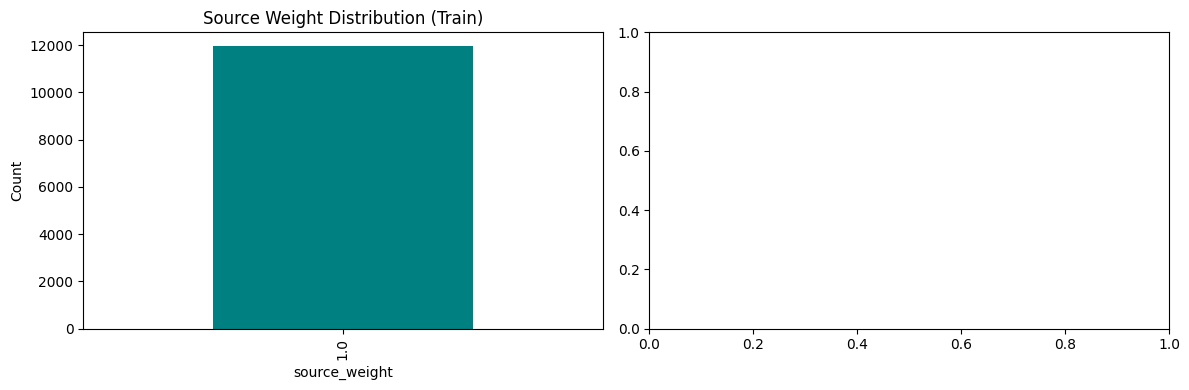

In [6]:
if 'source_weight' in df_train.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Weight distribution
    ax = axes[0]
    df_train['source_weight'].value_counts().sort_index().plot(
        kind='bar', ax=ax, color='teal'
    )
    ax.set_title('Source Weight Distribution (Train)')
    ax.set_xlabel('source_weight')
    ax.set_ylabel('Count')

    # Negative type breakdown
    ax = axes[1]
    if 'negative_type' in df_train.columns:
        df_train['negative_type'].value_counts().plot(
            kind='bar', ax=ax, color='coral'
        )
        ax.set_title('Negative Type Breakdown (Train)')
        ax.set_xlabel('negative_type')
        ax.set_ylabel('Count')

    plt.tight_layout()
    plt.show()
else:
    print('source_weight column not present in training manifest.')

## Preprocessing Complete
All splits validated. Proceed to `Team505_EDA.ipynb` for
exploratory analysis, then run model notebooks for training.